In [1]:
!pip install numpy pandas xarray matplotlib pystac-client planetary-computer rioxarray rasterio scikit-learn scipy

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pystac_client import Client
import planetary_computer
import rioxarray as rio
from rioxarray.merge import merge_arrays
from rasterio.enums import Resampling

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

from scipy.ndimage import distance_transform_edt

In [3]:
catalog_url = "https://planetarycomputer.microsoft.com/api/stac/v1"

s2_collection = "sentinel-2-l2a"
dem_collection = "cop-dem-glo-30"
wordcover_collection = "esa-worldcover"

training_bbox = [-51.30, -30.10, -51.10, -29.90]
dem_asset_candidates = ["data", "dem", "elevation"]
wordcover_asset_candidates = ["map", "data", "classification"]
permanent_water_class = 80

wet_threshold = 0.10

In [4]:
# Searches for satellite tiles in the catalog
def search_items(catalog, collection, bbox, datetime=None, query=None):
    search = catalog.search(
        collections=[collection],   
        bbox=bbox,
        datetime=datetime,
        query=query
    )

    items = list(search.get_items())
    if not items:
        raise ValueError(f"No STAC items found for collection={collection}, bbox={bbox}, datetime={datetime}")
    return items

In [5]:
# Returns the key images
def pick_asset_key(item, candidates):
    for key in candidates:
        if key in item.assets:
            return key
    raise KeyError(f"None of {candidates} found in item assets: {list(item.assets.keys())}")

In [6]:
def open_asset_and_clip(item, asset_key, bbox):
    signed_href = planetary_computer.sign(item.assets[asset_key].href)
    da = rio.open_rasterio(signed_href, masked=True).squeeze(drop=True)
    clipped = da.rio.clip_box(
        minx=bbox[0],
        miny=bbox[1],
        maxx=bbox[2],
        maxy=bbox[3],
        crs="EPSG:4326"
    )

    return clipped

In [7]:
def mossaic_collection(items, asset_candidates, bbox):
    layers = []
    for item in items:
        try:
            asset_key = pick_asset_key(item, asset_candidates)
            clipped = open_asset_and_clip(item, asset_key, bbox)
            layers.append(clipped)
        except Exception:
            continue

    if not layers:
        raise ValueError("No overlapping assets could be clipped for the requested bbox.")
    
    if len(layers) == 1:
        return layers[0]
    
    return merge_arrays(layers)

In [8]:
def sentinel_monthly_ndwi(catalog, bbox, datetime_range, cloud_lt=30, max_scenes=6):
    items = search_items(
        catalog,
        s2_collection,
        bbox,
        datetime=datetime_range,
        query={"eo:cloud_cover": {"lt": cloud_lt}}
    )

    items = sorted(items, key=lambda it: it.properties.get("eo:cloud_cover", 100.0))
    selected = items[:max_scenes]
    if not selected:
        raise ValueError(f"No Sentinel-2 scenes selected for {datetime_range}")
    
    ndwi_scenes = []
    for item in selected:
        green = open_asset_and_clip(item, "B03", bbox)
        nir = open_asset_and_clip(item, "B08", bbox)

        if green.shape != nir.shape or green.rio.crs != nir.rio.crs:
            nir = nir.rio.reproject_match(green, resampling=Resampling.bilinear)

        denom = green + nir
        ndwi = xr.where(np.abs(denom) > 1e-6, (green - nir) / denom, np.nan)
        ndwi = ndwi.rio.write_crs(green.rio.crs)
        ndwi_scenes.append(ndwi)

    ndwi_stack = xr.concat(ndwi_scenes, dim="scene")
    ndwi_median = ndwi_stack.median(dim="scene", skipna=True)
    ndwi_median = ndwi_median.rio.write_crs(ndwi_scenes[0].rio.crs)
    return ndwi_median

In [9]:
# creates flood mask based on the wet threshold
def make_flood_mask(ndwi_baseline, ndwi_flood, wet_threshold=wet_threshold):
    ndwi_flood_aligned = ndwi_flood.rio.reproject_match(ndwi_baseline, resampling=Resampling.bilinear)

    wet_before = ndwi_baseline > wet_threshold
    wet_after = ndwi_flood_aligned > wet_threshold

    flood_mask = xr.where((~wet_before) & wet_after, 1, 0).astype("uint8")
    flood_mask = flood_mask.rio.write_crs(ndwi_baseline.rio.crs)
    return flood_mask

In [10]:
def compute_slope_degrees(elevation_da):
    transform = elevation_da.rio.transform()
    x_res = abs(transform.a)
    y_res = abs(transform.e)

    z = elevation_da.values.astype("float32")
    dz_dy, dz_dx = np.gradient(z, y_res, x_res)
    slope_deg = np.degrees(np.arctan(np.hypot(dz_dx, dz_dy))).astype("float32")

    slope_da = xr.DataArray(
        slope_deg,
        coords=elevation_da.coords,
        dims=elevation_da.dims,
        name="slope"
    )
    slope_da = slope_da.rio.write_crs(elevation_da.rio.crs)
    return slope_da

In [11]:
# Calculate the distance from water to land
def compute_distance_to_water(permanent_water_mask):
    water = permanent_water_mask.values.astype(bool)
    non_water = ~water

    dist_px = distance_transform_edt(non_water).astype("float32")

    transform = permanent_water_mask.rio.transform()
    pixel_size_m = float((abs(transform.a) + abs(transform.e)) / 2.0)
    dist_m = dist_px * pixel_size_m

    dist_da = xr.DataArray(
        dist_m,
        coords=permanent_water_mask.coords,
        dims=permanent_water_mask.dims,
        name="dist_to_water_m"
    )

    mask_crs = permanent_water_mask.rio.crs
    if mask_crs is None:
        return dist_da

    return dist_da.rio.write_crs(mask_crs)


In [12]:
# Returns mossaic images of DEM and Worldcover
def load_dem_and_worldcover(catalog, bbox):
    dem_items = search_items(catalog, dem_collection, bbox)
    wc_items = search_items(catalog, wordcover_collection, bbox)

    dem = mossaic_collection(dem_items, dem_asset_candidates, bbox).astype("float32")
    wc = mossaic_collection(wc_items, wordcover_asset_candidates, bbox)

    return dem, wc

In [13]:
def align_training_layers(dem, wc, sentinel_template):
    elevation = dem.rio.reproject_match(sentinel_template, resampling=Resampling.bilinear)
    slope = compute_slope_degrees(elevation)

    landcover = wc.rio.reproject_match(sentinel_template, resampling=Resampling.nearest)
    landcover = landcover.round().astype("int16")

    build_flag = xr.where(landcover == 50, 1, 0).astype("uint16")
    permanent_water_mask = xr.where(landcover == permanent_water_class, 1, 0).astype("uint8")
    permanent_water_mask = permanent_water_mask.rio.write_crs(landcover.rio.crs)
    dist_to_water = compute_distance_to_water(permanent_water_mask)

    return elevation, slope, landcover, build_flag, permanent_water_mask, dist_to_water


In [14]:
# Builds the training dataframe by validating elevation, slope, landcover and flood mask
def training_dataframe(elevation, slope, landcover, flood_mask, dist_to_water, permanent_water_mask):
    elev = elevation.values.reshape(-1)
    slp = slope.values.reshape(-1)
    lc = landcover.values.reshape(-1)
    y = flood_mask.values.reshape(-1)
    d2w = dist_to_water.values.reshape(-1)
    perm = permanent_water_mask.values.reshape(-1)

    valid = (
        np.isfinite(elev)
        & np.isfinite(slp)
        & np.isfinite(lc)
        & np.isfinite(y)
        & np.isfinite(d2w)
        & (perm == 0)
    )

    df = pd.DataFrame({
        "elevation": elev[valid],
        "slope": slp[valid],
        "landcover": lc[valid].astype(np.int16),
        "distance_to_water_m": d2w[valid].astype(np.float32),
        "flood": y[valid].astype(np.uint8)
    })

    return df

In [15]:
# Trains a simple Random Forest to predict the flood
def train_rf(df):
    if df["flood"].nunique() < 2:
        raise ValueError("Flood target has a single class. Try different dates or thresholds.")

    X = df[["elevation", "slope", "landcover", "distance_to_water_m"]]
    y = df["flood"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )

    model.fit(X_train, y_train)

    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs >= 0.5).astype(np.uint8)

    print("Model evaluation on holdout set")
    print(classification_report(y_test, y_pred, digits=3))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_probs), 4))

    return model


In [16]:
# Creates the feature matrix
def build_feature_matrix(elevation, slope, landcover, dist_to_water, permanent_water_mask):
    elev = elevation.values.reshape(-1)
    slp = slope.values.reshape(-1)
    lc = landcover.values.reshape(-1)
    d2w = dist_to_water.values.reshape(-1)

    valid = np.isfinite(elev) & np.isfinite(slp) & np.isfinite(lc) & np.isfinite(d2w)

    if permanent_water_mask is not None:
        perm = permanent_water_mask.values.reshape(-1).astype(bool)
        valid = valid & (~perm)

    X = np.column_stack([
        elev[valid],
        slp[valid],
        lc[valid],
        d2w[valid]
    ])

    return X, valid, landcover.shape

In [17]:
# Predicts the risk of an area based on landcover, elevation and slope
def predict_risk(bbox, model, catalog):
    dem, wc = load_dem_and_worldcover(catalog, bbox)

    landcover = wc.round().astype("int16")
    permanent_water_mask = xr.where(landcover == permanent_water_class, 1, 0).astype("uint8")
    permanent_water_mask = permanent_water_mask.rio.write_crs(landcover.rio.crs)

    elevation = dem.rio.reproject_match(landcover, resampling=Resampling.bilinear)
    slope = compute_slope_degrees(elevation)
    dist_to_water = compute_distance_to_water(permanent_water_mask)

    X, valid, out_shape = build_feature_matrix(elevation, slope, landcover, dist_to_water, permanent_water_mask)

    prob_flat = np.full(out_shape[0] * out_shape[1], np.nan, dtype="float32")
    if X.size > 0:
        prob_flat[valid] = model.predict_proba(X)[:, 1]

    heatmap = prob_flat.reshape(out_shape)

    risk_da = xr.DataArray(
        heatmap,
        coords=landcover.coords,
        dims=landcover.dims,
        name="flood_risk"
    )

    risk_da = risk_da.rio.write_crs(landcover.rio.crs)
    return risk_da

In [18]:
def main():
    catalog = Client.open(catalog_url)

    # Training label generation
    ndwi_may_2023 = sentinel_monthly_ndwi(catalog, training_bbox, "2023-05-01/2023-05-31")
    ndwi_may_2024 = sentinel_monthly_ndwi(catalog, training_bbox, "2024-05-01/2024-05-31")
    flood_mask = make_flood_mask(ndwi_may_2023, ndwi_may_2024, wet_threshold=wet_threshold)

    # Feature layers
    dem, wc = load_dem_and_worldcover(catalog, training_bbox, )
    elevation, slope, landcover, build_flag, permanent_water_mask, dist_to_water = align_training_layers(
        dem, wc, ndwi_may_2023
    )

    # Train model
    train_df = training_dataframe(
        elevation, slope, landcover, flood_mask, dist_to_water, permanent_water_mask
    )
    model = train_rf(train_df)

    risk_heatmap = predict_risk(training_bbox, model, catalog)

    plt.figure(figsize=(10, 8))
    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad(color="lightblue")

    masked = np.ma.masked_invalid(risk_heatmap.values)
    plt.imshow(masked, cmap=cmap, vmin=0.0, vmax=1.0)
    plt.colorbar(label="Flood risk probability")
    plt.title("Flood Risk Heatmap (Permanent Water Masked)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(
/tmp/ipykernel_5359/1739194286.py:28: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'y' ('y',) The recommendation is to set join explicitly for this case.
  ndwi_stack = xr.concat(ndwi_scenes, dim="scene")
/usr/local/lib/python3.12/dist-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(
/tmp/ipykernel_5359/1739194286.py:28: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' b

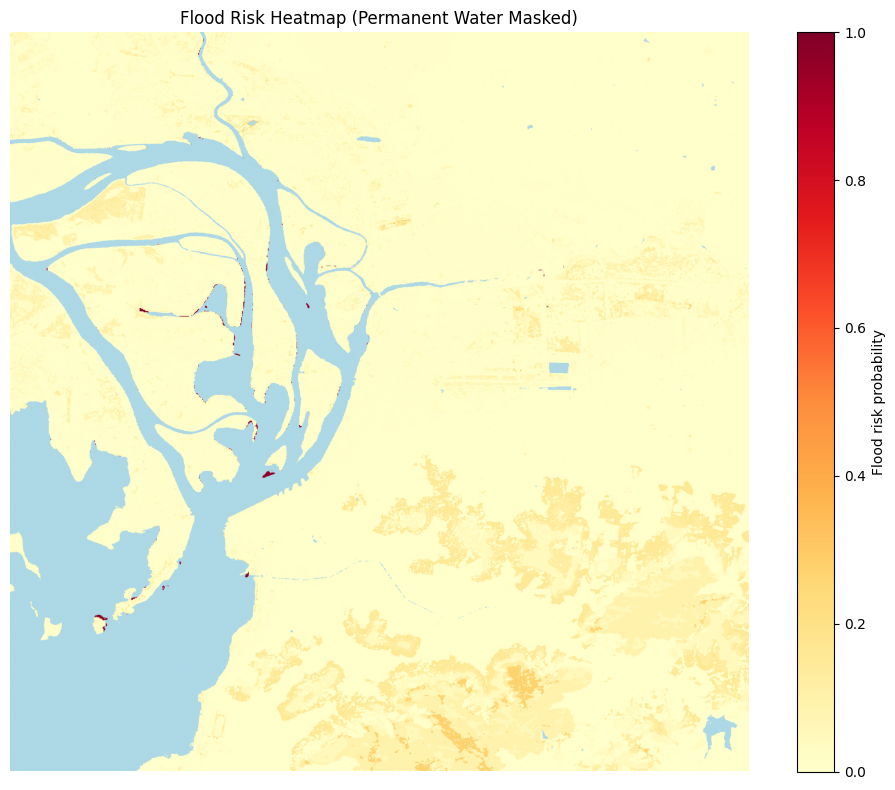

In [19]:
main()